# Predicción de demanda eléctrica con Python y ML

**Python Exposition Day 2026** · Taller de 1 h 40 min · Deniz Arriaza

---

Vamos a construir, de principio a fin, un modelo que pronostica la demanda eléctrica
**con 24 horas de anticipación**: hoy a las 10 de la mañana queremos saber cuánta
energía se va a necesitar mañana, hora por hora.

Ese detalle —las 24 horas de anticipación— define todo lo demás. Es la diferencia
entre un ejercicio de juguete y un modelo que sirve.

### Cómo usar este notebook

1. `Archivo → Guardar una copia en Drive` antes de tocar nada.
2. Corre las celdas en orden con `Shift + Enter`.
3. Donde diga **`# TODO`** te toca escribir código. Si te atoras, la versión
   resuelta está en el mismo repositorio.

### Ruta

| Bloque | Tema |
|---|---|
| 1 | Anatomía de la demanda |
| 2 | Baselines y métricas |
| 3 | Ingeniería de variables |
| 4 | XGBoost y validación temporal |
| 5 | Evaluación e interpretación |
| 6 | De notebook a producción |

In [1]:
# --- Instalación (solo lo que Colab no trae) ---
import importlib, subprocess, sys

for pkg in ["shap", "holidays", "xgboost"]:
    try:
        importlib.import_module(pkg)
    except ImportError:
        print(f"instalando {pkg}...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Paleta del taller
TINTA, PAPEL, AMBAR, TEAL, TERRA = "#121A24", "#F7F3ED", "#E09B2D", "#1F6F6B", "#B5503A"
mpl.rcParams.update({
    "figure.figsize": (11, 4), "figure.facecolor": PAPEL, "axes.facecolor": "white",
    "axes.edgecolor": "#DED5C8", "axes.labelcolor": TINTA, "axes.titlesize": 13,
    "axes.titleweight": "bold", "axes.grid": True, "grid.color": "#EDE5DA",
    "text.color": TINTA, "xtick.color": "#6E665C", "ytick.color": "#6E665C",
    "font.size": 10, "legend.frameon": False,
})

pd.set_option("display.width", 120)
def revisar(d):
    # Avisa si alguna columna quedó sin completar. Un `...` sin resolver crea una
    # columna de tipo object que no falla aquí, pero revienta diez celdas después
    # con un error de XGBoost imposible de interpretar.
    malas = [c for c in d.columns if d[c].dtype == object]
    if malas:
        raise NotImplementedError(
            "Faltan por completar estas columnas: " + ", ".join(malas) +
            ".\nVuelve al # TODO de esta celda (o de una anterior) y escribe el código.")
    return d


print("Listo. numpy", np.__version__, "| pandas", pd.__version__)

Listo. numpy 2.1.3 | pandas 2.2.3


## Los datos

Dos opciones:

- **Datos reales.** Pon en `URL_DATOS` la URL o la ruta de un CSV con demanda
  horaria. El cargador no asume el formato: prueba separadores (`,` `;` tab) y
  decimales, detecta las columnas por nombre, admite fecha y hora en columnas
  separadas (incluida la convención 1–24 del AMM), ordena, quita duplicados y
  avisa de los datos faltantes.
- **Datos sintéticos.** Si dejas `URL_DATOS` vacío, generamos una serie realista:
  tres estacionalidades, efecto no lineal del clima, feriados de Guatemala y
  ruido que se comporta como el de verdad.

El generador existe por una razón muy práctica: en un taller de cien personas
conectadas al mismo wifi, depender de una descarga en vivo es pedir problemas.

In [2]:
URL_DATOS = ""   # <- pega aquí la URL de tu CSV, o déjalo vacío para datos sintéticos

PERFIL_HORARIO = np.array([
    0.880, 0.845, 0.822, 0.812, 0.815, 0.838, 0.888, 0.945,
    0.975, 0.995, 1.008, 1.012, 1.005, 0.998, 0.995, 1.000,
    1.035, 1.105, 1.180, 1.205, 1.160, 1.080, 0.985, 0.920,
])
FACTOR_DIA = {0: 1.000, 1: 1.012, 2: 1.015, 3: 1.010, 4: 0.992, 5: 0.922, 6: 0.878}


def feriados_gt(idx):
    # Devuelve dos series booleanas: (es feriado, es Semana Santa)
    anios = list(range(idx.year.min(), idx.year.max() + 1))
    try:
        import holidays
        cal = holidays.Guatemala(years=anios)
        fechas = set(cal.keys())
        SS = {"Jueves Santo", "Viernes Santo", "Sábado Santo"}
        santa = {d for d, nombre in cal.items() if nombre in SS}
    except Exception:
        # Respaldo sin dependencias: Semana Santa se calcula desde la Pascua
        from dateutil.easter import easter
        from datetime import timedelta
        fechas, santa = set(), set()
        for a in anios:
            p = easter(a)
            ss = [p - timedelta(days=3), p - timedelta(days=2), p - timedelta(days=1)]
            santa.update(ss); fechas.update(ss)
            fechas.update({pd.Timestamp(a, m, d).date() for m, d in
                           [(1, 1), (5, 1), (6, 30), (9, 15), (10, 20), (11, 1), (12, 25)]})
    d = idx.date
    return (pd.Series([x in fechas for x in d], index=idx),
            pd.Series([x in santa for x in d], index=idx))


def generar_serie(inicio="2023-01-01", fin="2025-12-31 23:00", semilla=7):
    # Serie horaria sintética de demanda (MW) y temperatura (°C)
    rng = np.random.default_rng(semilla)
    idx = pd.date_range(inicio, fin, freq="h")
    n = len(idx)
    hora, doy = idx.hour.to_numpy(), idx.dayofyear.to_numpy()

    # Temperatura: ciclo anual + ciclo diario + ruido con memoria
    ruido_t = np.zeros(n); e = rng.normal(0, 1.1, n)
    for i in range(1, n):
        ruido_t[i] = 0.90 * ruido_t[i - 1] + e[i]
    temp = (19.5 + 3.0 * np.sin(2 * np.pi * (doy - 100) / 365.25)
            + 5.5 * np.sin(2 * np.pi * (hora - 9) / 24) + ruido_t)

    # Demanda
    tendencia = 1500.0 * (1 + 0.035) ** (np.arange(n) / 8766.0)   # ~3.5% anual
    perfil = PERFIL_HORARIO[hora]
    factor_dia = np.array([FACTOR_DIA[d] for d in idx.dayofweek])

    fer, ss = feriados_gt(idx)
    factor_fer = np.where(ss.to_numpy(), 0.80, np.where(fer.to_numpy(), 0.87, 1.0))

    # Clima: forma de U, dominada por refrigeración
    efecto_clima = (15.0 * np.clip(temp - 22.0, 0, None) ** 1.30
                    + 7.0 * np.clip(15.5 - temp, 0, None) ** 1.20)

    # Nivel diario con memoria (actividad económica)
    dias = idx.normalize().unique()
    nivel = np.zeros(len(dias)); ed = rng.normal(0, 0.014, len(dias))
    for i in range(1, len(dias)):
        nivel[i] = 0.55 * nivel[i - 1] + ed[i]
    factor_nivel = pd.Series(1.0 + nivel, index=dias).reindex(idx.normalize()).to_numpy()

    # Ruido con memoria, más fuerte en la hora pico
    escala = 1.0 + 1.9 * np.clip(perfil - 1.0, 0, None) / 0.205
    ruido = np.zeros(n); e2 = rng.normal(0, 1, n)
    for i in range(1, n):
        ruido[i] = 0.72 * ruido[i - 1] + e2[i]

    mw = (tendencia * perfil * factor_dia * factor_fer * factor_nivel
          + efecto_clima + ruido * 10.5 * escala)

    return pd.DataFrame({"mw": mw.round(1), "temp_c": temp.round(2)},
                        index=idx).rename_axis("fecha_hora")


def cargar_csv_demanda(origen, col_fecha=None, col_hora=None, col_mw=None, col_temp=None):
    # Carga un CSV de demanda horaria sin asumir el formato exacto: prueba
    # separadores y decimales comunes, detecta las columnas por nombre, admite
    # fecha y hora en columnas separadas, ordena, quita duplicados y rellena
    # vacios cortos. Si tu archivo es raro, pasa los nombres a mano.
    bruto = None
    for kw in [{"sep": ",", "decimal": "."}, {"sep": ";", "decimal": ","},
               {"sep": ";", "decimal": "."}, {"sep": "\t", "decimal": "."}]:
        try:
            t = pd.read_csv(origen, **kw)
            if t.shape[1] >= 2:
                bruto = t
                break
        except Exception:
            continue
    if bruto is None:
        raise ValueError("No pude leer el CSV. Pásale los parámetros a pandas tú mismo.")

    bruto.columns = [str(c).strip() for c in bruto.columns]

    def buscar(claves, excluir=()):
        for c in bruto.columns:
            n = c.lower()
            if any(x in n for x in excluir):
                continue
            if any(k in n for k in claves):
                return c
        return None

    f = col_fecha or buscar(["fecha", "date", "dia", "periodo"]) or bruto.columns[0]
    h = col_hora or buscar(["hora", "hour", "hr"], excluir=["fecha", "date"])
    m = col_mw or buscar(["mw", "demanda", "carga", "load", "potencia", "energia"])
    if m is None:
        num = [c for c in bruto.select_dtypes("number").columns if c not in (f, h)]
        m = num[0] if num else bruto.columns[-1]
    tc = col_temp or buscar(["temp"])

    # Índice temporal: una sola columna, o fecha + hora por separado
    ts = pd.to_datetime(bruto[f], errors="coerce")
    if ts.isna().mean() > 0.2:
        ts = pd.to_datetime(bruto[f], errors="coerce", dayfirst=True)
    if h is not None and h != f:
        hh = pd.to_numeric(bruto[h], errors="coerce")
        if hh.notna().any() and hh.max() <= 24:
            if hh.min() >= 1 and hh.max() == 24:
                hh = hh - 1          # convención 1..24 (la del AMM) → 0..23
            ts = ts.dt.normalize() + pd.to_timedelta(hh.clip(0, 23), unit="h")

    d = pd.DataFrame({"mw": pd.to_numeric(bruto[m], errors="coerce")})
    if tc is not None and tc not in (m, f, h):
        d["temp_c"] = pd.to_numeric(bruto[tc], errors="coerce")
    d.index = ts
    d = d[d.index.notna() & d["mw"].notna()]
    d = d[~d.index.duplicated(keep="first")].sort_index()
    if d.empty:
        raise ValueError(f"No quedaron filas válidas. Detecté fecha='{f}', hora='{h}', mw='{m}'.")

    # Rejilla horaria completa; vacios cortos se interpolan, los largos se avisan
    completo = pd.date_range(d.index.min(), d.index.max(), freq="h")
    vacios = len(completo) - len(d)
    d = d.reindex(completo).rename_axis("fecha_hora")
    largos = d["mw"].isna().groupby(d["mw"].notna().cumsum()).sum().max()
    d = d.interpolate(limit=3, limit_direction="both")

    print(f"CSV cargado · fecha='{f}'" + (f", hora='{h}'" if h and h != f else "")
          + f", mw='{m}'" + (f", temp='{tc}'" if "temp_c" in d else ""))
    print(f"{len(d):,} horas · de {d.index.min()} a {d.index.max()}")
    if vacios:
        print(f"⚠ {vacios} horas faltaban; el vacio más largo era de {int(largos or 0)} h.")
        print("  Los vacios de hasta 3 h se interpolaron. Si hay más largos, revísalos:")
        print("  un apagón NO es demanda baja, es demanda no servida. Márcalo, no lo promedies.")
    if "temp_c" not in d:
        print("⚠ Sin columna de temperatura: el notebook corre igual, pero el bloque de")
        print("  clima quedará vacío. Puedes traerla de Open-Meteo con la misma rejilla horaria.")
    return d


if URL_DATOS:
    df = cargar_csv_demanda(URL_DATOS)
else:
    df = generar_serie()
    print("Datos sintéticos generados")

print(f"{len(df):,} horas · de {df.index.min()} a {df.index.max()}")
df.head()

Datos sintéticos generados
26,304 horas · de 2023-01-01 00:00:00 a 2025-12-31 23:00:00


,mw,temp_c
fecha_hora,,
2023-01-01 00:00:00,1033.0,12.64
2023-01-01 01:00:00,998.4,12.09
2023-01-01 02:00:00,983.3,11.21
2023-01-01 03:00:00,977.4,10.04
2023-01-01 04:00:00,977.3,9.83


In [3]:
# Lo primero, siempre: ¿hay vacios? ¿hay duplicados? ¿el índice está completo?
esperado = pd.date_range(df.index.min(), df.index.max(), freq="h")

print("Horas esperadas :", len(esperado))
print("Horas presentes :", len(df))
print("Faltantes       :", len(esperado.difference(df.index)))
print("Duplicadas      :", int(df.index.duplicated().sum()))
print("Nulos por columna:")
print(df.isna().sum())
df.describe().round(1)

Horas esperadas : 26304
Horas presentes : 26304
Faltantes       : 0
Duplicadas      : 0
Nulos por columna:
mw        0
temp_c    0
dtype: int64


,mw,temp_c
count,26304.0,26304.0
mean,1536.1,19.4
std,212.4,5.1
min,977.3,3.8
25%,1371.4,15.6
50%,1527.8,19.4
75%,1675.9,23.2
max,2299.7,34.4


---
# Bloque 1 · Anatomía de la demanda

Antes de modelar, mirar. La serie tiene **tres relojes corriendo al mismo tiempo**
—el del día, el de la semana y el del año— y un termómetro encima.

Si entiendes estos patrones, la ingeniería de variables del bloque 3 se vuelve obvia.

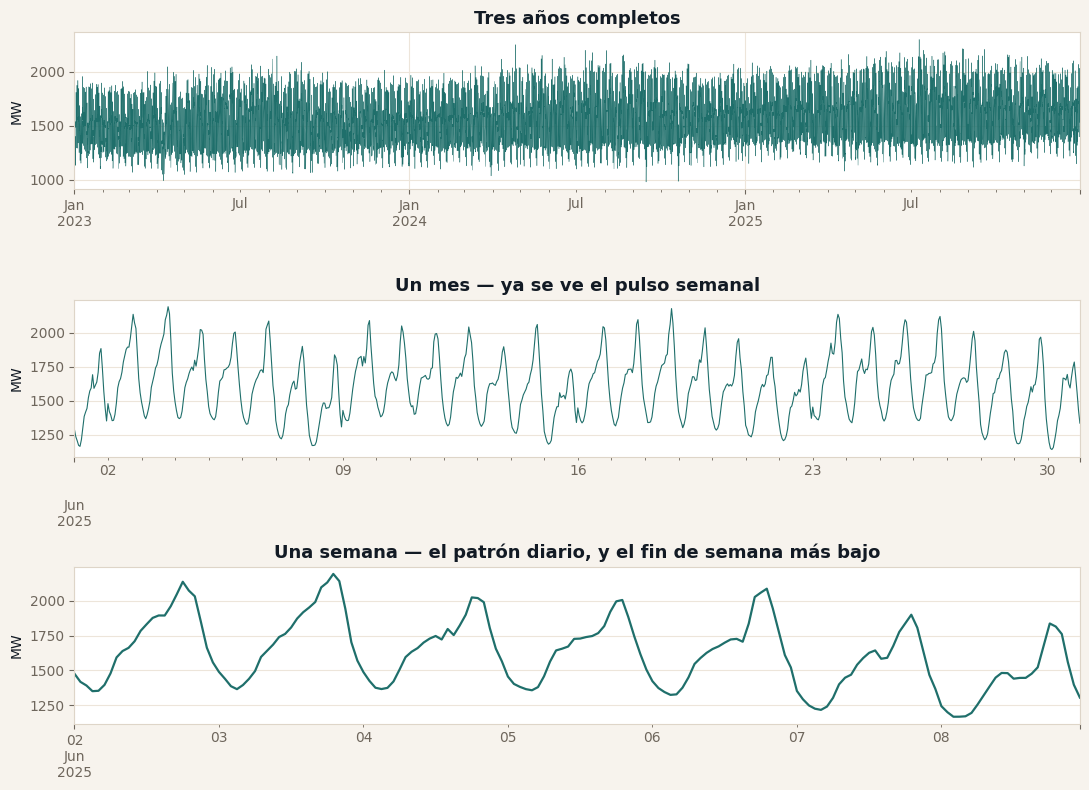

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8))

df["mw"].plot(ax=axes[0], color=TEAL, lw=0.3)
axes[0].set_title("Tres años completos")

df.loc["2025-06", "mw"].plot(ax=axes[1], color=TEAL, lw=0.8)
axes[1].set_title("Un mes — ya se ve el pulso semanal")

df.loc["2025-06-02":"2025-06-08", "mw"].plot(ax=axes[2], color=TEAL, lw=1.6)
axes[2].set_title("Una semana — el patrón diario, y el fin de semana más bajo")

for a in axes:
    a.set_xlabel(""); a.set_ylabel("MW")
plt.tight_layout(); plt.show()

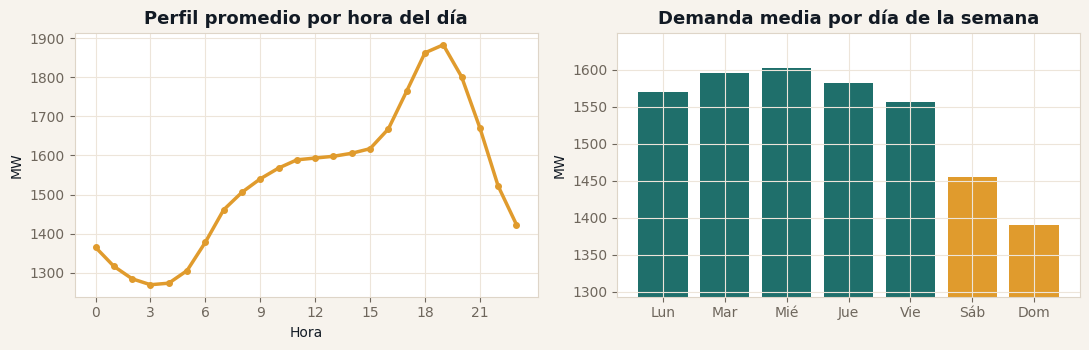

Valle :  3h  →  1,269 MW
Pico  : 19h  →  1,883 MW
El pico es 48% más alto que el valle.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

perfil = df["mw"].groupby(df.index.hour).mean()
axes[0].plot(perfil.index, perfil.values, color=AMBAR, lw=2.5, marker="o", ms=4)
axes[0].set_title("Perfil promedio por hora del día")
axes[0].set_xlabel("Hora"); axes[0].set_ylabel("MW"); axes[0].set_xticks(range(0, 24, 3))

dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
por_dia = df["mw"].groupby(df.index.dayofweek).mean()
colores = [TEAL] * 5 + [AMBAR] * 2
axes[1].bar(dias, por_dia.values, color=colores)
axes[1].set_title("Demanda media por día de la semana")
axes[1].set_ylabel("MW"); axes[1].set_ylim(por_dia.min() * 0.93, por_dia.max() * 1.03)

plt.tight_layout(); plt.show()

print(f"Valle : {perfil.idxmin():>2}h  →  {perfil.min():,.0f} MW")
print(f"Pico  : {perfil.idxmax():>2}h  →  {perfil.max():,.0f} MW")
print(f"El pico es {perfil.max()/perfil.min() - 1:.0%} más alto que el valle.")

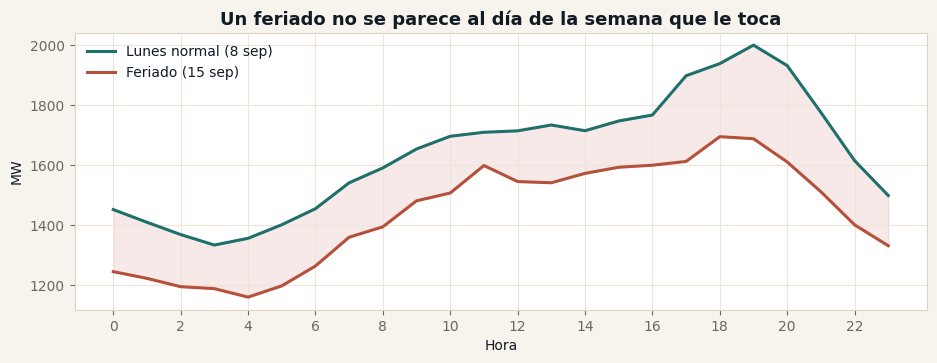

Energía consumida ese feriado: 12.2% menos que un lunes normal.


In [6]:
# ¿Qué le pasa a la demanda en un feriado?
fer, ss = feriados_gt(df.index)
df["es_feriado"] = fer.astype(int).to_numpy()
df["es_semana_santa"] = ss.astype(int).to_numpy()

ind = df.loc["2025-09-15"]           # Día de la Independencia (lunes)
normal = df.loc["2025-09-08"]        # el lunes anterior, sin feriado

plt.figure(figsize=(11, 3.6))
plt.plot(range(24), normal["mw"].values, color=TEAL, lw=2.2, label="Lunes normal (8 sep)")
plt.plot(range(24), ind["mw"].values, color=TERRA, lw=2.2, label="Feriado (15 sep)")
plt.fill_between(range(24), ind["mw"].values, normal["mw"].values,
                 color=TERRA, alpha=0.12)
plt.title("Un feriado no se parece al día de la semana que le toca")
plt.xlabel("Hora"); plt.ylabel("MW"); plt.xticks(range(0, 24, 2)); plt.legend()
plt.show()

caida = 1 - ind["mw"].sum() / normal["mw"].sum()
print(f"Energía consumida ese feriado: {caida:.1%} menos que un lunes normal.")

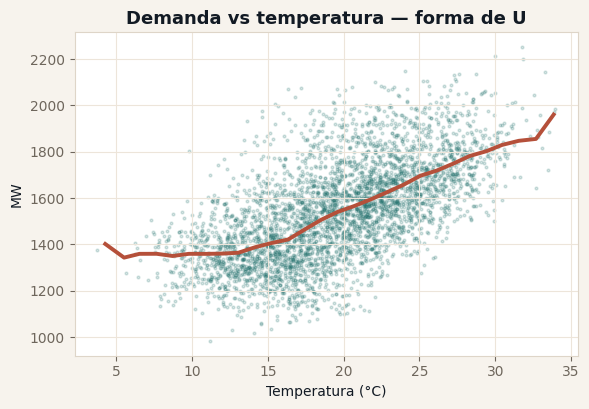

Sube con el calor (refrigeración) y sube con el frío (calefacción).
Una regresión lineal simple no ve esta forma; un árbol sí.


In [7]:
# La relación con el clima no es una línea recta
muestra = df.sample(4000, random_state=1)

plt.figure(figsize=(6.5, 4.2))
plt.scatter(muestra["temp_c"], muestra["mw"], s=4, alpha=0.18, color=TEAL)

# Media de demanda por bin de temperatura
bins = pd.cut(df["temp_c"], bins=28)
curva = df.groupby(bins, observed=True).agg(t=("temp_c", "mean"), m=("mw", "mean"))
plt.plot(curva["t"], curva["m"], color=TERRA, lw=2.8)

plt.title("Demanda vs temperatura — forma de U")
plt.xlabel("Temperatura (°C)"); plt.ylabel("MW")
plt.show()

print("Sube con el calor (refrigeración) y sube con el frío (calefacción).")
print("Una regresión lineal simple no ve esta forma; un árbol sí.")

---
# Bloque 2 · Baselines y métricas

## Primero: ¿qué estamos prediciendo, exactamente?

Pronosticamos **con 24 horas de anticipación**. Cuando predecimos las 7 p.m. de
mañana, lo último que conocemos es la demanda de hasta hace 24 horas.

Esto tiene una consecuencia que la mayoría de tutoriales ignora:

> **`lag_1` no existe.** El dato de la hora anterior a la que estás prediciendo
> todavía no ha ocurrido.

Un modelo entrenado con `lag_1` da métricas preciosas y es **inservible en
producción**, porque el día que lo conectes ese dato no va a estar. Todas las
variables de este notebook respetan la regla: nada posterior a `t - 24 h`.

In [8]:
def mae(y, p):
    y, p = np.asarray(y, float), np.asarray(p, float)
    return float(np.mean(np.abs(y - p)))

def rmse(y, p):
    y, p = np.asarray(y, float), np.asarray(p, float)
    return float(np.sqrt(np.mean((y - p) ** 2)))

def mape(y, p):
    y, p = np.asarray(y, float), np.asarray(p, float)
    return float(np.mean(np.abs((y - p) / y)) * 100)


# El marcador que vamos a ir llenando durante todo el taller
MARCADOR = []

def anotar(nombre, y, p):
    MARCADOR.append({"modelo": nombre, "MAE (MW)": round(mae(y, p), 1),
                     "RMSE (MW)": round(rmse(y, p), 1), "MAPE (%)": round(mape(y, p), 2)})
    return pd.DataFrame(MARCADOR)

print("Métricas listas.")

Métricas listas.


In [9]:
CORTE = "2025-10-01"     # todo lo anterior entrena; lo posterior es la prueba final

# Baseline 1: ayer a la misma hora
df["naive_24"] = df["mw"].shift(24)
# Baseline 2: hace exactamente una semana, misma hora
df["naive_168"] = df["mw"].shift(168)

prueba = df.loc[CORTE:].dropna(subset=["naive_24", "naive_168"])

anotar("Naïve · ayer  y(t-24)", prueba["mw"], prueba["naive_24"])
anotar("Naïve · semana pasada  y(t-168)", prueba["mw"], prueba["naive_168"])
pd.DataFrame(MARCADOR)

,modelo,MAE (MW),RMSE (MW),MAPE (%)
0,Naïve · ayer y(t-24),86.9,115.4,5.51
1,Naïve · semana pasada y(t-168),56.9,80.2,3.59


El naïve semanal gana por bastante, y la razón es interesante: **`y(t-168)` ya trae
empaquetadas dos cosas a la vez** —la misma hora del día *y* el mismo día de la semana—.
Ayer a esta hora puede ser un domingo comparado con un lunes.

Ese es el listón. Si el XGBoost no lo supera, no tenemos un modelo: tenemos un
notebook bonito.

### Sobre las métricas

- **MAE** en MW. La que entiende cualquiera: "nos equivocamos en promedio 59 MW".
- **RMSE** castiga fuerte los errores grandes. Úsala si un fallo gordo te duele
  mucho más que diez pequeños.
- **MAPE** en %. La que te van a pedir en la reunión.

⚠️ Cuidado con el MAPE cuando la demanda es baja: dividir entre un número pequeño
infla el porcentaje. En la madrugada, el MAPE exagera.

---
# Bloque 3 · Ingeniería de variables

Aquí es donde de verdad se gana el modelo. Vamos a convertir una columna de números
en una tabla que un árbol pueda entender.

**La regla que no se rompe:** ninguna variable puede usar información posterior a
`t - 24 h`. Vamos a definir el horizonte una sola vez y respetarlo en todo.

In [12]:
H = 24   # horizonte del pronóstico, en horas

d = df[["mw", "temp_c"]].copy()
print(f"Horizonte: {H} h. Ninguna variable puede mirar más allá de t-{H}.")

Horizonte: 24 h. Ninguna variable puede mirar más allá de t-24.


In [15]:
# --- 1. LAGS ---
# TODO: crea las columnas lag_24, lag_25, lag_48, lag_168 y lag_336
#       Pista: d["mw"].shift(L)
#       ¿Por qué el más corto es 24 y no 1?

for L in [24, 25, 48, 168, 336]:
    d[f"lag_{L}"] = d["mw"].shift(L)

revisar(d)
d[["mw", "lag_24", "lag_168"]].tail(3)

,mw,lag_24,lag_168
fecha_hora,,,
2025-12-31 21:00:00,1843.7,1837.3,1848.4
2025-12-31 22:00:00,1629.1,1699.1,1673.7
2025-12-31 23:00:00,1531.3,1600.6,1566.4


In [21]:
# --- 2. VENTANAS MÓVILES ---
# TODO: media de las últimas 24 h, media de las últimas 168 h y desviación de 24 h.
#       CUIDADO: el .shift(H) va ANTES del .rolling().
#       Sin él, la ventana incluye el valor que quieres predecir.

d["roll_24"] = d["mw"].shift(H).rolling(24).mean()
d["roll_168"] = d["mw"].shift(H).rolling(168).mean()
d["std_24"] = d["mw"].shift(H).rolling(24).std()
d["std_168"] = d["mw"].shift(H).rolling(168).std()

revisar(d)
d[["mw", "roll_24", "roll_168", "std_24"]].tail(3)

,mw,roll_24,roll_168,std_24
fecha_hora,,,,
2025-12-31 21:00:00,1843.7,1678.583333,1554.019048,188.908933
2025-12-31 22:00:00,1629.1,1684.079167,1554.077976,187.440569
2025-12-31 23:00:00,1531.3,1689.470833,1554.066667,182.855941


In [20]:
# --- 3. CALENDARIO Y CODIFICACIÓN CÍCLICA ---
d["hora"] = d.index.hour
d["dia_sem"] = d.index.dayofweek
d["mes"] = d.index.month
d["dia_anio"] = d.index.dayofyear

# TODO: codifica la hora sobre un círculo con seno y coseno, y haz lo mismo
#       con el día de la semana. ¿Por qué hacen falta DOS columnas por ciclo?
d["h_sin"] = np.sin(2 * np.pi * d["hora"] / 24)
d["h_cos"] = np.cos(2 * np.pi * d["hora"] / 24)
d["ds_sin"] = np.sin(2 * np.pi * d["dia_sem"] / 7)
d["ds_cos"] = np.cos(2 * np.pi * d["dia_sem"] / 7)

revisar(d)
p23 = np.array([np.sin(2*np.pi*23/24), np.cos(2*np.pi*23/24)])
p00 = np.array([0.0, 1.0])
p12 = np.array([np.sin(2*np.pi*12/24), np.cos(2*np.pi*12/24)])
print(f"Distancia 23h → 0h  : {np.linalg.norm(p23 - p00):.3f}")
print(f"Distancia 12h → 0h  : {np.linalg.norm(p12 - p00):.3f}")

Distancia 23h → 0h  : 0.261
Distancia 12h → 0h  : 2.000


In [22]:
# --- 4. FERIADOS ---
# Semana Santa va aparte: no cae en fecha fija y pega más fuerte que un feriado normal.
fer, ss = feriados_gt(d.index)
d["es_feriado"] = fer.astype(int).to_numpy()
d["es_semana_santa"] = ss.astype(int).to_numpy()

# El día antes y el día después de un feriado también se comportan distinto
d["vispera"] = d["es_feriado"].shift(-24).fillna(0).astype(int)
d["post_feriado"] = d["es_feriado"].shift(24).fillna(0).astype(int)

# Un momento: ¿"vispera" no está mirando el futuro con ese shift(-24)?
# No, y la distinción importa. Hay dos tipos de variable:
#   · OBSERVADAS (demanda, y en la práctica el clima): solo puedes usar el
#     pasado disponible, hasta t-24. Aquí aplica la regla estricta.
#   · DE CALENDARIO (hora, día, feriados): se conocen con años de anticipación.
#     Saber hoy que mañana es 15 de septiembre no es trampa; está en el almanaque.
# La prueba práctica: ¿tendrás este dato el día del pronóstico? Con el calendario,
# siempre sí.

print("Feriados en el periodo:", int(d["es_feriado"].groupby(d.index.date).max().sum()), "días")
print("De ellos, Semana Santa:", int(d["es_semana_santa"].groupby(d.index.date).max().sum()), "días")

Feriados en el periodo: 33 días
De ellos, Semana Santa: 0 días


In [23]:
# --- 5. CLIMA ---
# OJO: para pronosticar mañana necesitas la temperatura DE MAÑANA, que a su vez
# es un pronóstico. Aquí usamos el valor observado; en producción entra el
# pronóstico meteorológico, con su propio error. Volvemos a esto en el bloque 6.
d["temp_media_24"] = d["temp_c"].rolling(24).mean()
d["temp_max_24"] = d["temp_c"].rolling(24).max()
d["calor"] = np.clip(d["temp_c"] - 22.0, 0, None)   # necesidad de enfriar
d["frio"] = np.clip(15.5 - d["temp_c"], 0, None)    # necesidad de calentar

d[["temp_c", "calor", "frio"]].describe().round(2)

,temp_c,calor,frio
count,26304.00,26304.00,26304.00
mean,19.43,1.05,0.66
std,5.11,2.02,1.54
min,3.75,0.00,0.00
25%,15.63,0.00,0.00
50%,19.40,0.00,0.00
75%,23.18,1.18,0.00
max,34.36,12.36,11.75


In [24]:
# --- 6. ENSAMBLAR ---
revisar(d)                                      # ¿quedó algún TODO sin completar?
d = d.dropna()                                  # los lags dejan vacios al inicio
COLS = [c for c in d.columns if c != "mw"]

print(f"{len(COLS)} variables, {len(d):,} filas utilizables")
print(f"De {d.index.min().date()} a {d.index.max().date()}")
print()
print(COLS)

26 variables, 25,968 filas utilizables
De 2023-01-15 a 2025-12-31

['temp_c', 'lag_24', 'lag_25', 'lag_48', 'lag_168', 'lag_336', 'roll_24', 'roll_168', 'std_24', 'hora', 'dia_sem', 'mes', 'dia_anio', 'h_sin', 'h_cos', 'ds_sin', 'ds_cos', 'std_168', 'es_feriado', 'es_semana_santa', 'vispera', 'post_feriado', 'temp_media_24', 'temp_max_24', 'calor', 'frio']


### Ejercicio · 6 minutos

Agrega **una variable tuya** y mira si mejora el modelo. Ideas para arrancar:

- ¿Es quincena o fin de mes? (`d.index.day`)
- Horas transcurridas desde el último feriado
- La interacción entre hora pico y temperatura
- Diferencia entre `lag_24` y `lag_168` (¿viene subiendo o bajando?)

Escríbela, corre el resto del notebook y anota tu MAPE. Al final comparamos.

In [32]:
# --- TU VARIABLE ---
# TODO: inventa una variable, agrégala a d y añádela a COLS.
#       Recuerda la regla: nada posterior a t-24.

#d["mi_variable"] = d.index.day
d["quincena"] = d.index.day.isin([14, 15, 16, 29, 30, 31]).astype(int)
d
revisar(d)
if "mi_variable" not in COLS:
    COLS.append("mi_variable")

print(f"Ahora son {len(COLS)} variables.")

Ahora son 27 variables.


/tmp/ipykernel_3156/1163585466.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d["mi_variable"] = d.index.day


---
# Bloque 4 · XGBoost y validación temporal

Entrenar es la parte corta. **Validar bien es lo que separa un modelo que sirve de
uno que solo se ve bien en el notebook.**

Empecemos por hacer trampa a propósito, para que veas cómo se siente.

In [28]:
# ══ DEMOSTRACIÓN DE LEAKAGE ══
# Un error clásico y silencioso: "suavizar" la serie ANTES de partir los datos.
# La ventana centrada mira una hora hacia adelante... incluida la que predecimos.

from xgboost import XGBRegressor

trampa = d.copy()
trampa["suavizado"] = df["mw"].rolling(3, center=True).mean().reindex(trampa.index)

cols_trampa = COLS + ["suavizado"]
tr_t, te_t = trampa.loc[:CORTE], trampa.loc[CORTE:]

m_trampa = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                        n_jobs=-1, random_state=7)
m_trampa.fit(tr_t[cols_trampa], tr_t["mw"])
mape_trampa = mape(te_t["mw"], m_trampa.predict(te_t[cols_trampa]))

print(f"MAPE con la variable contaminada: {mape_trampa:.2f}%")
print("Espectacular. Y completamente falso: esa columna contiene el futuro.")
print("En producción no existe, y el modelo se desploma el primer día.")

MAPE con la variable contaminada: 0.55%
Espectacular. Y completamente falso: esa columna contiene el futuro.
En producción no existe, y el modelo se desploma el primer día.


In [30]:
# ══ EL SPLIT CORRECTO: por fecha, nunca aleatorio ══
# TODO: parte d en train (hasta CORTE) y test (desde CORTE).
#       Luego separa los últimos 60 días del train como validación.

#train = d.loc[:CORTE]
#test = d.loc[CORTE:]
train, test = d.loc[:CORTE], d.loc[CORTE:]

corte_val = train.index.max() - pd.Timedelta(days=60)
tr_fit = train.loc[:corte_val]
tr_val = train.loc[corte_val:]

print(f"Entrenamiento : {tr_fit.index.min().date()} → {tr_fit.index.max().date()}  ({len(tr_fit):,})")
print(f"Validación    : {tr_val.index.min().date()} → {tr_val.index.max().date()}  ({len(tr_val):,})")
print(f"Prueba final  : {test.index.min().date()} → {test.index.max().date()}  ({len(test):,})")

Entrenamiento : 2023-01-15 → 2025-08-02  (22,344)
Validación    : 2025-08-02 → 2025-10-01  (1,441)
Prueba final  : 2025-10-01 → 2025-12-31  (2,208)


In [34]:
def entrenar(cols, **kw):
    # TODO: completa los hiperparámetros. Puntos de partida razonables:
    #   n_estimators 3000 (alto, que el early stopping corte)
    #   learning_rate 0.04 · max_depth 6 · subsample 0.8
    #   colsample_bytree 0.8 · min_child_weight 5 · early_stopping_rounds 60
    params = dict(
        n_estimators=3000,
        learning_rate=0.04,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        early_stopping_rounds=60,
        n_jobs=-1,
        random_state=7
    )
    params.update(kw)
    m = XGBRegressor(**params)
    m.fit(
        tr_fit[cols], tr_fit["mw"],
        eval_set=[(tr_val[cols], tr_val["mw"])],
        verbose=False
    )
    return m

CLIMA = ["temp_c", "temp_media_24", "temp_max_24", "calor", "frio"]
sin_clima = [c for c in COLS if c not in CLIMA]

m_base = entrenar(sin_clima)
anotar("XGBoost · sin clima", test["mw"], m_base.predict(test[sin_clima]))

modelo = entrenar(COLS)
pred = modelo.predict(test[COLS])
anotar("XGBoost · con clima", test["mw"], pred)

print(f"Árboles usados: {m_base.best_iteration} sin clima, {modelo.best_iteration} con clima\n")
pd.DataFrame(MARCADOR)

Árboles usados: 158 sin clima, 1322 con clima



,modelo,MAE (MW),RMSE (MW),MAPE (%)
0,Naïve · ayer y(t-24),86.9,115.4,5.51
1,Naïve · semana pasada y(t-168),56.9,80.2,3.59
2,XGBoost · sin clima,36.1,47.3,2.24
3,XGBoost · con clima,34.6,43.8,2.14


In [ ]:
# ══ ¿Y si hubiéramos partido al azar? ══
from sklearn.model_selection import train_test_split

Xa, Xb, ya, yb = train_test_split(d[COLS], d["mw"], test_size=0.2,
                                  shuffle=True, random_state=7)
m_azar = XGBRegressor(n_estimators=max(modelo.best_iteration, 50), learning_rate=0.04,
                      max_depth=6, subsample=0.8, colsample_bytree=0.8,
                      min_child_weight=5, n_jobs=-1, random_state=7)
m_azar.fit(Xa, ya)
mape_azar = mape(yb, m_azar.predict(Xb))
mape_real = mape(test["mw"], pred)

print(f"Split aleatorio : {mape_azar:5.2f}%   <- el número que te gustaría reportar")
print(f"Corte por fecha : {mape_real:5.2f}%   <- el número verdadero")
print(f"\nRegalo: {(1 - mape_azar/mape_real):.0%} de error que no era tuyo.")
print("No siempre es catastrófico. El problema es que no sabes cuánto te está mintiendo.")

In [ ]:
# ══ VALIDACIÓN CRUZADA TEMPORAL ══
# Un solo corte puede tener suerte. TimeSeriesSplit hace varios, siempre
# entrenando con el pasado y validando con el futuro inmediato.
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5, test_size=24 * 30)   # un mes por fold
scores = []

for i, (idx_tr, idx_va) in enumerate(tscv.split(train), 1):
    a, b = train.iloc[idx_tr], train.iloc[idx_va]
    m = XGBRegressor(n_estimators=modelo.best_iteration or 300, learning_rate=0.04,
                     max_depth=6, subsample=0.8, colsample_bytree=0.8,
                     min_child_weight=5, n_jobs=-1, random_state=7)
    m.fit(a[COLS], a["mw"])
    s = mape(b["mw"], m.predict(b[COLS]))
    scores.append(s)
    print(f"Fold {i}: entrena {len(a):>6,} filas → valida {b.index.min().date()}  MAPE {s:.2f}%")

print(f"\nMAPE medio {np.mean(scores):.2f}%  ±{np.std(scores):.2f}")
print("La desviación entre folds te dice qué tan estable es el modelo.")

---
# Bloque 5 · Evaluación e interpretación

Un MAPE global no dice nada útil. Lo que importa es **dónde** falla el modelo y
**por qué** decide lo que decide.

In [ ]:
res = test.copy()
res["pred"] = pred
res["error"] = res["pred"] - res["mw"]
res["ape"] = (res["error"].abs() / res["mw"]) * 100

semana = res.loc["2025-12-08":"2025-12-14"]

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                         gridspec_kw={"height_ratios": [2.2, 1]})
axes[0].plot(semana.index, semana["mw"], color=TINTA, lw=2, label="Real")
axes[0].plot(semana.index, semana["pred"], color=AMBAR, lw=2, ls="--", label="Pronóstico")
axes[0].set_ylabel("MW"); axes[0].legend()
axes[0].set_title("Una semana del periodo de prueba")

axes[1].axhline(0, color="#BBB", lw=1)
axes[1].fill_between(semana.index, semana["error"], color=TERRA, alpha=0.45)
axes[1].set_ylabel("Error (MW)")
axes[1].set_title("El error se concentra en los picos")

plt.tight_layout(); plt.show()

In [ ]:
por_hora = res.groupby(res.index.hour)["ape"].mean()
peor, mejor = por_hora.idxmax(), por_hora.idxmin()

plt.figure(figsize=(11, 3.6))
colores = [TERRA if h == peor else TEAL for h in por_hora.index]
plt.bar(por_hora.index, por_hora.values, color=colores)
plt.title("MAPE por hora del día — el promedio esconde dónde duele")
plt.xlabel("Hora"); plt.ylabel("MAPE (%)"); plt.xticks(range(0, 24))
plt.show()

print(f"Peor hora  : {peor:>2}h  →  {por_hora.max():.2f}%")
print(f"Mejor hora : {mejor:>2}h  →  {por_hora.min():.2f}%")
print(f"\nLa hora pico es la que define la compra de energía.")
print(f"Un {por_hora.max():.1f}% ahí cuesta mucho más que un {por_hora.min():.1f}% de madrugada.")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

# Feriados vs días normales
comp = res.groupby("es_feriado")["ape"].mean()
axes[0].bar(["Día normal", "Feriado"], [comp.get(0, np.nan), comp.get(1, np.nan)],
            color=[TEAL, TERRA], width=0.55)
axes[0].set_title("MAPE: feriado vs día normal"); axes[0].set_ylabel("MAPE (%)")

# ¿Queda estructura en los residuales?
axes[1].scatter(res["pred"], res["error"], s=5, alpha=0.2, color=TEAL)
axes[1].axhline(0, color=TERRA, lw=1.5)
axes[1].set_title("Residuales vs predicción")
axes[1].set_xlabel("Pronóstico (MW)"); axes[1].set_ylabel("Error (MW)")

plt.tight_layout(); plt.show()

print("Si los residuales tuvieran forma (embudo, curva, bandas), quedaría señal sin capturar.")

sesgo = res["error"].mean()
print(f"\nSesgo medio: {sesgo:+.1f} MW  ({sesgo / res['mw'].mean():+.2%} de la demanda media)")
if sesgo < 0:
    print("\nEl modelo se queda CORTO de forma sistemática. No es casualidad:")
    print("un árbol solo predice valores que vio en el entrenamiento, así que")
    print("no extrapola la tendencia de crecimiento. Compruébalo:")
    crec = test['lag_168'].mean() / train['lag_168'].mean() - 1
    print(f"  la demanda del periodo de prueba es {crec:+.1%} vs la del entrenamiento.")
    print("\nSoluciones: modelar la tendencia aparte, trabajar con diferencias,")
    print("o reentrenar seguido para que el desfase nunca crezca mucho.")

In [ ]:
# ══ SHAP: por qué el modelo decidió eso ══
import shap

muestra = test.sample(min(800, len(test)), random_state=7).sort_index()
explainer = shap.TreeExplainer(modelo)
sv = explainer(muestra[COLS])

shap.plots.bar(sv, max_display=12, show=False)
plt.title("Importancia global (SHAP)", pad=12)
plt.tight_layout(); plt.show()

In [ ]:
# Una sola predicción, desarmada: de dónde sale cada MW
hora_pico = muestra.index[muestra.index.hour == 19][0]
i = muestra.index.get_loc(hora_pico)

print(f"Explicando {hora_pico}  ·  real {muestra['mw'].iloc[i]:,.0f} MW")
shap.plots.waterfall(sv[i], max_display=10, show=False)
plt.gcf().set_size_inches(10, 5.5)
plt.tight_layout(); plt.show()

print("\nEste gráfico es el que convence a un jefe. Úsalo cuando te pregunten")
print("por qué el modelo dijo lo que dijo.")
print("\nOJO: importancia no es causalidad. Dice cómo USA el modelo la variable,")
print("no cómo funciona el mundo.")

---
# Bloque 6 · De notebook a producción

La parte que los tutoriales se saltan y la que decide si tu modelo sirve dentro de
seis meses.

In [ ]:
# ══ MONITOREO: el MAPE móvil es tu alarma ══
diario = res.resample("D").agg(mape_dia=("ape", "mean"))
diario["mape_movil_7d"] = diario["mape_dia"].rolling(7).mean()

plt.figure(figsize=(11, 3.4))
plt.plot(diario.index, diario["mape_dia"], color="#C9BFB2", lw=1, label="MAPE diario")
plt.plot(diario.index, diario["mape_movil_7d"], color=TERRA, lw=2.5, label="Media móvil 7 días")
plt.axhline(diario["mape_dia"].mean(), color=TEAL, ls="--", lw=1.5, label="Promedio del periodo")
plt.title("Lo que vigilas cuando el modelo ya está corriendo")
plt.ylabel("MAPE (%)"); plt.legend()
plt.show()

print("Si la línea roja sube dos semanas seguidas, algo cambió en el sistema:")
print("reentrena, o investiga qué se movió.")

In [ ]:
# ══ DRIFT: ¿los datos de hoy se parecen a los del entrenamiento? ══
print("Variable          entrenamiento        prueba         cambio")
print("-" * 62)
for c in ["temp_c", "roll_168", "lag_168"]:
    a, b = train[c].mean(), test[c].mean()
    print(f"{c:16s} {a:12,.1f} {b:14,.1f} {(b/a - 1):+13.1%}")

print("\nUn cambio grande no es un error, pero sí una señal de que el modelo")
print("está operando fuera del rango donde aprendió.")

In [ ]:
# ══ EL ESLABÓN MÁS DÉBIL: el clima también es un pronóstico ══
# Simulamos un error típico de pronóstico meteorológico (±1.5 °C) y medimos
# cuánto se degrada nuestro modelo de demanda.
rng = np.random.default_rng(3)
test_ruido = test.copy()
error_clima = rng.normal(0, 1.5, len(test_ruido))

test_ruido["temp_c"] += error_clima
test_ruido["calor"] = np.clip(test_ruido["temp_c"] - 22.0, 0, None)
test_ruido["frio"] = np.clip(15.5 - test_ruido["temp_c"], 0, None)

mape_ideal = mape(test["mw"], pred)
mape_real_clima = mape(test_ruido["mw"], modelo.predict(test_ruido[COLS]))

print(f"Con temperatura observada  : {mape_ideal:.2f}%")
print(f"Con temperatura pronosticada: {mape_real_clima:.2f}%")
print(f"Degradación: {mape_real_clima - mape_ideal:+.2f} puntos")
print("\nTu modelo hereda el error del pronóstico del clima. Casi nadie lo mide.")

In [ ]:
# ══ GUARDAR EL MODELO ══
import json

modelo.save_model("modelo_demanda.json")
with open("metadatos_modelo.json", "w", encoding="utf-8") as f:
    json.dump({
        "horizonte_horas": H,
        "corte_entrenamiento": CORTE,
        "variables": COLS,
        "n_arboles": int(modelo.best_iteration or 0),
        "mape_prueba": round(mape(test["mw"], pred), 3),
        "entrenado_hasta": str(train.index.max()),
    }, f, indent=2, ensure_ascii=False)

print("Guardados: modelo_demanda.json y metadatos_modelo.json")
print("\nGuarda SIEMPRE la lista de variables junto al modelo. El día que lo cargues")
print("en otro lado, el orden de las columnas importa y nadie lo recuerda.")

---
# El marcador final

In [ ]:
final = pd.DataFrame(MARCADOR)
final["mejora vs anterior"] = (
    final["MAPE (%)"].shift(1).sub(final["MAPE (%)"]).div(final["MAPE (%)"].shift(1))
    .map(lambda x: "—" if pd.isna(x) else f"{x:+.0%}")
)
final

---

## Lo que nos llevamos

1. **El horizonte define las variables.** Pronosticar a 24 horas significa que
   `lag_1` no existe. Definirlo al principio evita un modelo que funciona en el
   notebook y se cae en producción.

2. **Baselines primero.** Si no le ganas al naïve semanal, no tienes un modelo.

3. **Corte por fecha, nunca aleatorio.** Y el `.shift()` antes del `.rolling()`.
   El leakage no da error: da métricas bonitas.

4. **Desagrega el error.** El MAPE global esconde que la hora pico —justo la que
   importa para comprar energía— es la peor.

5. **El 80 % del trabajo es el dato.** Limpiar, alinear zonas horarias, marcar
   apagones. Modelar es la última tarde.

6. **Un modelo que nadie consume no existe.** La entrega pesa tanto que la métrica.

## Para seguir

- Cambia `CORTE` y mira si las conclusiones aguantan en otro periodo.
- Prueba regresión cuantílica (`objective="reg:quantileerror"`) para tener bandas
  en lugar de un solo número.
- Compara contra LightGBM y contra un modelo lineal con las mismas variables.
  Te va a sorprender lo cerca que queda el lineal.
- Aplica el mismo flujo a otra serie: ventas, tráfico, consumo de agua. Cambia el
  dominio, no el método.

---

**¿Preguntas?** Este notebook es tuyo. Rómpelo.